<a href="https://colab.research.google.com/github/vySebas/MineriaDeDatos/blob/main/Lab01_EDA_Yucra_Sebastian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Nombre del dataset: Titanic – Machine Learning from Disaster
*   Autor o publicador: Simon
*   Enlace: https://www.kaggle.com/datasets/shuofxz/titanic-machine-learning-from-disaster
*   Archivo seleccionado: train.csv
*   Unidad de análisis: Cada fila representa a un pasajero individual a bordo del Titanic
*   Justificación: Elegí esta fuente porque ofrece una estructura clara de variables numéricas y categóricas, adecuada para cumplir con los requisitos exploratorios del laboratorio.
*   Pregunta inicial: Me interesa explorar qué relación existe entre la clase del boleto de un pasajero, su sexo y sus probabilidades de supervivencia.
*   Licencia o condiciones de uso: Open Database, Contents License.




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


La salida del código confirma que las librerias han sido cargadas correctamente. En este análisis, pandas manejará la tabla de datos, NumPy ayudará a reconocer las columnas numéricas, y Matplotlib junto con seaborn servirán para construir los gráficos.

In [ ]:
from google.colab import files
archivos_subidos = files.upload()
nombre_csv = next(iter(archivos_subidos))
print("Archivo seleccionado:", nombre_csv)

Saving train.csv to train (1).csv
Archivo seleccionado: train (1).csv


In [ ]:
df = pd.read_csv(nombre_csv)
print("Dataset cargado correctamente")
df.head()

Dataset cargado correctamente


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


In [ ]:
filas, columnas = df.shape
print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

Cantidad de filas: 891
Cantidad de columnas: 12


El dataset contiene 891 filas y 12 columnas. Cada fila representa a un pasajero a bordo del Titanic

In [ ]:
display(df.head())
display(df.tail())
display(df.sample(n=min(5, len(df)), random_state=42))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.00,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.00,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.00,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.00,0,0,370376,7.75,NaN,Q


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.25,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.00,0,0,C.A. 18723,10.50,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.00,0,0,SOTON/O2 3101287,7.92,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.00,0,1,248727,33.00,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.00,1,0,2651,11.24,NaN,C


Las filas se comprenden bien y representan a cada pasajero, con nombres de columna claros en su mayoría. Existen identificadores evidentes como PassengerId, Name y Ticket

In [ ]:
print("Columnas disponibles:")
for numero, columna in enumerate(df.columns, start=1):
    print(numero, "-", columna)

Columnas disponibles:
1 - PassengerId
2 - Survived
3 - Pclass
4 - Name
5 - Sex
6 - Age
7 - SibSp
8 - Parch
9 - Ticket
10 - Fare
11 - Cabin
12 - Embarked


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
resumen_columnas = pd.DataFrame({
"tipo_pandas": df.dtypes.astype(str),
"datos_presentes": df.notna().sum(),
"datos_nulos": df.isna().sum(),
"valores_unicos": df.nunique(dropna=True)
})
resumen_columnas

,tipo_pandas,datos_presentes,datos_nulos,valores_unicos
PassengerId,int64,891,0,891
Survived,int64,891,0,2
Pclass,int64,891,0,3
Name,object,891,0,891
Sex,object,891,0,2
Age,float64,714,177,88
SibSp,int64,891,0,7
Parch,int64,891,0,7
Ticket,object,891,0,681
Fare,float64,891,0,248


In [ ]:
columnas_numericas = df.select_dtypes(
include=np.number
).columns.tolist()
columnas_categoricas = df.select_dtypes(
include=["object", "category", "bool"]
).columns.tolist()
print("Columnas numericas:", columnas_numericas)
print("Columnas categoricas:", columnas_categoricas)

Columnas numericas: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Columnas categoricas: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


El código detecta 7 columnas numéricas y 5 columnas categóricas

In [ ]:
resumen_nulos = pd.DataFrame({
"cantidad_nulos": df.isnull().sum(),
"porcentaje_nulos": (df.isnull().mean() *
100).round(2)
})
resumen_nulos = resumen_nulos.sort_values(
by="porcentaje_nulos",
ascending=False
)
resumen_nulos


,cantidad_nulos,porcentaje_nulos
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [ ]:
columnas_con_nulos = resumen_nulos[
resumen_nulos["cantidad_nulos"] > 0
]
columnas_con_nulos

,cantidad_nulos,porcentaje_nulos
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


Las columnas con más datos faltantes son Cabin (aprox. 77% de nulos) y Age (aprox. 20%).

In [ ]:
cantidad_duplicados = df.duplicated().sum()
porcentaje_duplicados = cantidad_duplicados / len(df) * 100
print("Filas duplicadas:", cantidad_duplicados)
print("Porcentaje duplicado:", round(porcentaje_duplicados, 2), " %")

Filas duplicadas: 0
Porcentaje duplicado: 0.0  %


In [ ]:
df[df.duplicated(keep=False)].head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


No se detectaron filas duplicadas exactas (0 duplicados, 0%).

In [ ]:
valores_diferentes = df.nunique(dropna=False).sort_values()
valores_diferentes

,0
Survived,2
Sex,2
Pclass,3
Embarked,4
Parch,7
SibSp,7
Age,89
Cabin,148
Fare,248
Ticket,681


Se detectaron columnas binarias como Survived y Sex. También, existen columnas categóricas con pocos grupos, como Pclass y Embarked y se observan posibles identificadores, como PassengerId y Name, debido a que poseen una altísima cantidad de valores distintos

In [ ]:
print(columnas_numericas)

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [ ]:
if columnas_numericas:
  resumen_numerico = df[columnas_numericas].describe().T
  display(resumen_numerico)
else:
  print("El dataset no tiene columnas numericas detectadas")


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.00,446.00,257.35,1.00,223.50,446.00,668.50,891.00
Survived,891.00,0.38,0.49,0.00,0.00,0.00,1.00,1.00
Pclass,891.00,2.31,0.84,1.00,2.00,3.00,3.00,3.00
Age,714.00,29.70,14.53,0.42,20.12,28.00,38.00,80.00
SibSp,891.00,0.52,1.10,0.00,0.00,0.00,1.00,8.00
Parch,891.00,0.38,0.81,0.00,0.00,0.00,0.00,6.00
Fare,891.00,32.20,49.69,0.00,7.91,14.45,31.00,512.33


In [ ]:
if columnas_numericas:
  comparacion_centro = pd.DataFrame({
  "media": df[columnas_numericas].mean(),
  "mediana": df[columnas_numericas].median(),
  "desviacion_estandar": df[columnas_numericas].std(),
  "minimo": df[columnas_numericas].min(),
  "maximo": df[columnas_numericas].max()
  })
display(comparacion_centro)


,media,mediana,desviacion_estandar,minimo,maximo
PassengerId,446.00,446.00,257.35,1.00,891.00
Survived,0.38,0.00,0.49,0.00,1.00
Pclass,2.31,3.00,0.84,1.00,3.00
Age,29.70,28.00,14.53,0.42,80.00
SibSp,0.52,0.00,1.10,0.00,8.00
Parch,0.38,0.00,0.81,0.00,6.00
Fare,32.20,14.45,49.69,0.00,512.33


Para la columna Age, la media y la mediana son cercanas, lo que indica una distribución relativamente simétrica. En cambio, para Fare, la media es mucho mayor que la mediana, lo que sugiere una fuerte asimetría con valores extremos altos.

In [ ]:
if columnas_numericas:
  tabla_percentiles = df[columnas_numericas].quantile(
  [0.00, 0.05, 0.25, 0.50, 0.75, 0.95, 1.00]
  ).T
  tabla_percentiles.columns = [
  "min", "p05", "p25", "p50_mediana",
  "p75", "p95", "max"
  ]
  display(tabla_percentiles)

,min,p05,p25,p50_mediana,p75,p95,max
PassengerId,1.00,45.50,223.50,446.00,668.50,846.50,891.00
Survived,0.00,0.00,0.00,0.00,1.00,1.00,1.00
Pclass,1.00,1.00,2.00,3.00,3.00,3.00,3.00
Age,0.42,4.00,20.12,28.00,38.00,56.00,80.00
SibSp,0.00,0.00,0.00,0.00,1.00,3.00,8.00
Parch,0.00,0.00,0.00,0.00,0.00,2.00,6.00
Fare,0.00,7.22,7.91,14.45,31.00,112.08,512.33


El 25% de los registros tiene un valor menor o igual a 7.91 en la tarifa, la mediana de la tarifa es 14.45, mientras la media es 32.20, por lo que es bastante superior. Entre el percentil 95 (112.08) y el máximo (512.33) existe una diferencia enorme, lo que podría indicar la presencia de valores válidos pero muy poco frecuentes, como los boletos más lujosos de primera clase.

In [ ]:
if columnas_categoricas:
  resumen_categorico = df[columnas_categoricas].describe().T
  display(resumen_categorico)
else:
  print("No se detectaron columnas categoricas")

,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


In [ ]:
print(columnas_categoricas)
# Cambia el indice si la primera columna no es adecuada.
columna_categorica = columnas_categoricas[1]
print("Columna elegida:", columna_categorica)

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Columna elegida: Sex


In [ ]:
frecuencia = df[columna_categorica].value_counts(
dropna=False
)
porcentaje = df[columna_categorica].value_counts(
dropna=False,
normalize=True
).mul(100).round(2)
tabla_frecuencias = pd.DataFrame({
"cantidad": frecuencia,
"porcentaje": porcentaje
})
tabla_frecuencias.head(15)


,cantidad,porcentaje
Sex,,
male,577,64.76
female,314,35.24


En la columna Sex, la categoría más frecuente es male (hombres), que representa aproximadamente el 65% de los registros, dominando sobre la categoría female (mujeres). No se observan categorías escritas de formas distintas que representen lo mismo

In [ ]:
print(columnas_numericas)
# Cambia el indice para elegir una variable significativa.
columna_numerica = columnas_numericas[3]
print("Columna elegida:", columna_numerica)

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Columna elegida: Age


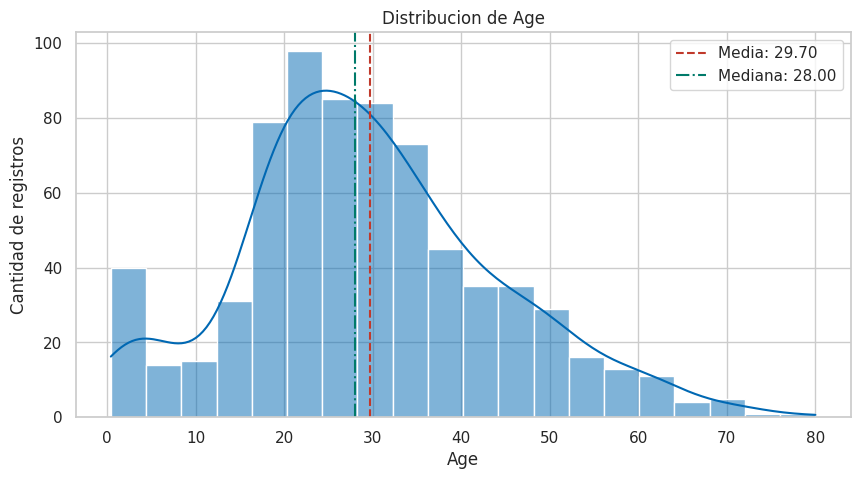

In [ ]:
media = df[columna_numerica].mean()
mediana = df[columna_numerica].median()

plt.figure(figsize=(10, 5))

sns.histplot(
  data=df,
  x=columna_numerica,
  bins=20,
  kde=True,
  color="#0068B3"
)

plt.axvline(
  media,
  color="#C0392B",
  linestyle="--",
  label=f"Media: {media:.2f}"
)

plt.axvline(
  mediana,
  color="#007A6A",
  linestyle="-.",
  label=f"Mediana: {mediana:.2f}"
)

plt.title(f"Distribucion de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.ylabel("Cantidad de registros")
plt.legend()
plt.show()




*   La mayoría de los valores se concentra entre los 28 y los 30 años.
*   La forma presenta una leve asimetría, pero la media y la mediana están muy cercanas entre sí.
*   Existe una concentración inusual cerca del cero (bebés y niños pequeños) y algunos valores aislados en el extremo derecho (hasta 80 años).
*   La forma de la distribución depende del límite natural de la edad biológica (que parte desde cero) y de la demografía real de los pasajeros a bordo.



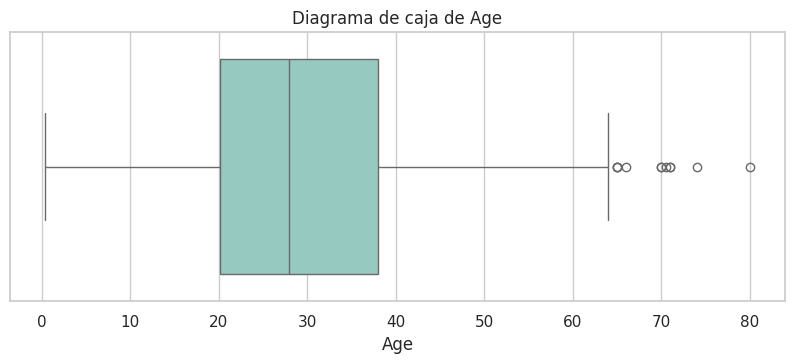

In [ ]:
plt.figure(figsize=(10, 3.5))
sns.boxplot(
x=df[columna_numerica],
color="#8ED1C6"
)
plt.title(f"Diagrama de caja de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.show()

La caja central agrupa al grueso de los pasajeros jóvenes y adultos (entre 20 y casi 40 años), siendo coherente con los percentiles calculados previamente.
Los puntos que aparecen alejados a la derecha de la caja (sobre los 65 años) son observaciones potencialmente extremas.
Estos puntos deben investigarse pero no deben borrarse automáticamente, ya que representan casos válidos e importantes de personas de la tercera edad que viajaban en el barco.

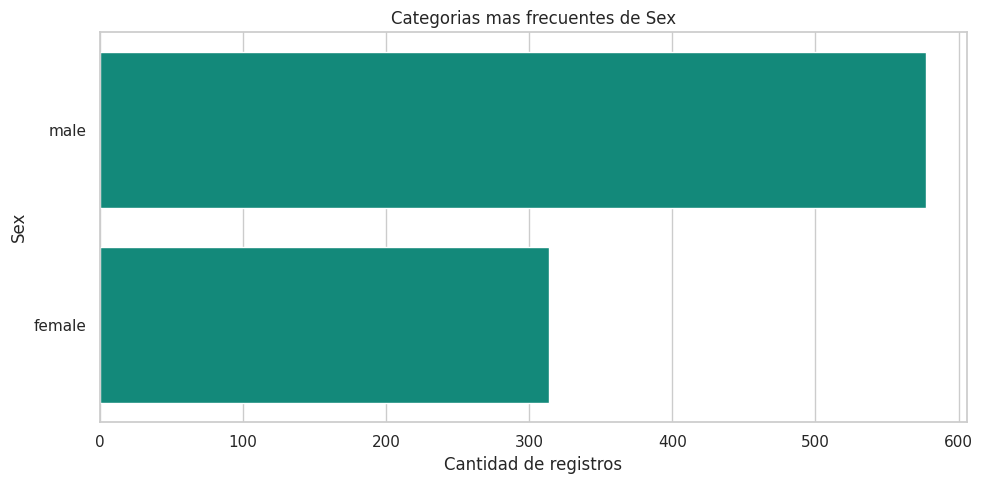

In [ ]:
top_categorias = df[columna_categorica].value_counts(
dropna=False
).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(
x=top_categorias.values,
y=top_categorias.index.astype(str),
color="#009C88"
)
plt.title(f"Categorias mas frecuentes de {columna_categorica}")
plt.xlabel("Cantidad de registros")
plt.ylabel(columna_categorica)
plt.tight_layout()
plt.show()

La categoría "male" (hombres) domina ampliamente, dejando en evidencia que los grupos no están equilibrados. Como esta variable solo tiene dos grupos, el gráfico no omite información y muestra las categorías completas.El resultado visual coincide directamente con la tabla de frecuencias anterior, ratificando la mayor presencia de hombres a bordo.

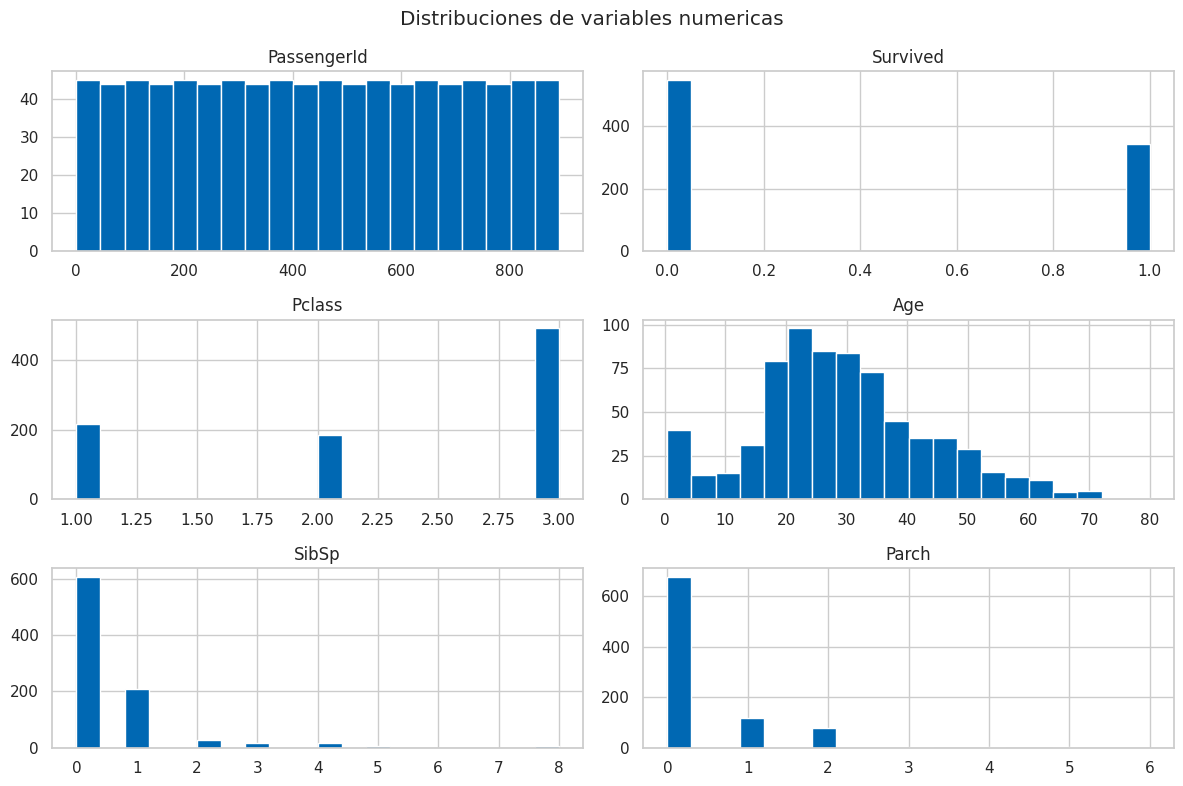

In [ ]:
seleccion_numericas = columnas_numericas[:6]
if seleccion_numericas:
  df[seleccion_numericas].hist(
    bins=20,
    figsize=(12, 8),
    color="#0068B3",
    edgecolor="white"
  )
plt.suptitle("Distribuciones de variables numericas")
plt.tight_layout()
plt.show()


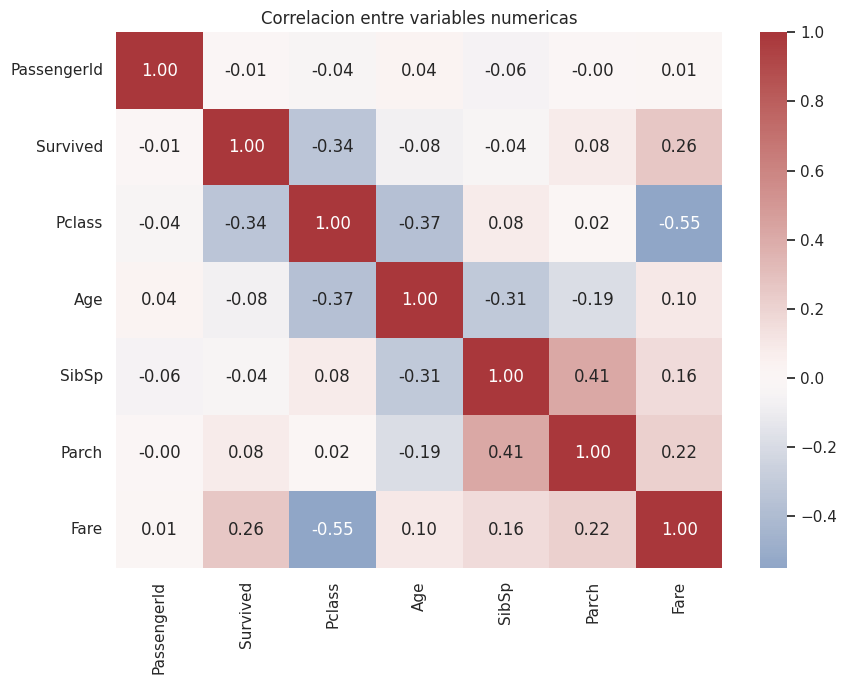

In [ ]:
seleccion_correlacion = columnas_numericas[:8]
if len(seleccion_correlacion) >= 2:
  matriz_correlacion = df[seleccion_correlacion].corr()
  plt.figure(figsize=(9, 7))
  sns.heatmap(
  matriz_correlacion,
  annot=True,
  fmt=".2f",
  cmap="vlag",
  center=0
)
plt.title("Correlacion entre variables numericas")
plt.tight_layout()
plt.show()


La asociación negativa más marcada ocurre entre Pclass (clase) y Fare (tarifa). Esto significa que a un mayor número de clase (ej. 3ra clase), el precio del boleto disminuye. Existe una asociación positiva entre SibSp (hermanos/esposos) y Parch (padres/hijos), demostrando que las familias tendían a viajar juntas. Tal como indica la teoría, estas correlaciones solo resumen la asociación lineal entre las variables y no significan causalidad.

9.-

*  **Tamaño y unidad**: El dataset consta de 891 filas y 12 columnas, donde cada fila es un pasajero único. Esto otorga una muestra sólida para buscar patrones demográficos, aunque queda la duda de si representa al total de los pasajeros o solo una fracción recuperada.
*  **Tipos de columnas**: La variable PassengerId es tratada por pandas como numérica (int64), pero es un simple identificador. Esto demuestra que el tipo técnico asignado por el sistema no siempre refleja el significado analítico, ya que promediar identificadores carece de sentido.
*   **Valores nulos**: Existen 177 valores nulos en Age (cerca del 20%) y una enorme cantidad en Cabin (aprox. 77%). No se puede asumir que estos nulos signifiquen cero; queda pendiente investigar si los registros de cabinas se perdieron durante el naufragio o si solo se registraban para pasajeros de primera clase.
*   **Duplicados**: Se encontró un 0% de filas duplicadas (0 registros). Esto confirma una excelente calidad inicial en la individualización de los datos, validando la regla de negocio de un pasajero por fila.
*   **Distribución numérica (Edad)**: La mediana de edad es de 28 años, con un fuerte sesgo hacia adultos jóvenes y una cola larga hasta los 80 años. La forma de la distribución responde a límites demográficos naturales.
*   **Categorías dominantes (Sexo)**: La categoría "male" domina la distribución gráfica y representa aproximadamente el 65% de las filas. Esto refleja un desequilibrio de género pronunciado en la composición de los pasajeros a bordo.
*  **Posibles valores extremos (Tarifa)**: Existe una brecha enorme en la variable Fare entre el percentil 95 (112.08) y el valor máximo (512.33). Estos puntos alejados observados en el diagrama de caja no son errores a borrar, sino que representan la existencia de pasajes de lujo extremos.



Este dataset es ideal para responder preguntas descriptivas sobre cómo factores socioeconómicos (clase, tarifa) y demográficos (sexo, edad) determinaron la supervivencia en el desastre. Sus principales fortalezas son la ausencia de duplicados y la claridad de sus variables. Sin embargo, antes de utilizarlo para construir un modelo predictivo, se debe resolver el problema de la alta cantidad de valores faltantes en las variables de edad y cabina, ya que podrían sesgar los resultados.

10.- El trabajo corresponde a la fase de Comprensión de los Datos de la metodología CRISP-DM, ya que el objetivo fue evaluar y familiarizarnos con la información sin llegar a modificarla ni transformarla. Durante el laboratorio validamos la procedencia de la fuente en Kaggle, identificamos la unidad de análisis y contrastamos el significado real de las variables con su tipo técnico asignado en pandas. Al examinar la calidad inicial mediante el recuento de nulos y duplicados, y al describir las distribuciones con estadística y gráficos exploratorios, logramos formular dudas y detectar problemas clave que obligatoriamente deben resolverse antes de poder avanzar a la etapa de Preparación de Datos.

# Aplicación de CRISP-DM


## 1. Comprensión del negocio
Se busca descubrir qué perfil de pasajero tenía más chances de salvarse en el Titanic. ¿Ser de primera clase, ser mujer o ser niño realmente te salvaba la vida? El objetivo es usar los datos para comprobar si la famosa regla de "mujeres y niños primero" se cumplió de verdad o si el dinero pesó más.

## 2. Comprensión de los datos
Al mirar la tabla de 891 pasajeros, se dio a conocer de que los datos no están perfectos. Faltan muchas edades (casi el 20%) y no tenemos ni idea de en qué cabina viajaba la mayoría (77% vacío). Además, vimos cosas lógicas pero fuertes, como que viajaban muchísimos más hombres que mujeres, o también que los de tercera clase eran la gran mayoría.

## 3. Preparación de los datos
Antes de armar el modelo, hay que hacer limpieza general. Hay que rellenar las edades que faltan (quizás usando un promedio), tirar a la basura la columna de cabinas porque está casi vacía, y transformar textos como "male" o "female" a números (0 y 1) para que se pueda calcular de manera mas sencilla.

## 4. Modelado
Se usará un modelo de clasificación. Esto funciona como un diagrama de flujo que tomará las características del pasajero y nos dará un veredicto.

## 5. Evaluación
Para saber si el modelo sirve, mediremos su exactitud. También revisaremos que no se confunda y sea capaz de identificar bien a los que realmente lograron sobrevivir.

## 6. Despliegue
Como el Titanic pasó hace más de cien años, no podemos usar esto para salvar gente hoy. La forma de "desplegar" este proyecto sería armar una pequeña página web interactiva, para que cualquier persona pueda evaluar su supervivencia.
